In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy as sp
import scipy.spatial
from sklearn.linear_model import Ridge
from sklearn.linear_model import LinearRegression
import sklearn as skl

In [ ]:
column_names = ['party'] + [f'vote_{i}' for i in range(1, 17)]
raw_data = pd.read_csv('house-votes-84.data', names=column_names)
raw_data.head()

,party,vote_1,vote_2,vote_3,vote_4,vote_5,vote_6,vote_7,vote_8,vote_9,vote_10,vote_11,vote_12,vote_13,vote_14,vote_15,vote_16
0,republican,n,y,n,y,y,y,n,n,n,y,?,y,y,y,n,y
1,republican,n,y,n,y,y,y,n,n,n,n,n,y,y,y,n,?
2,democrat,?,y,y,?,y,y,n,n,n,n,y,n,y,y,n,n
3,democrat,n,y,y,n,?,y,n,n,n,n,y,n,y,n,n,y
4,democrat,y,y,y,n,y,y,n,n,n,n,y,?,y,y,y,y


In [ ]:
party_map = {'democrat': 1, 'republican': -1}
y_train = raw_data['party'].map(party_map)
# y_train = raw_data['party'].map(lambda x: 1 if x == 'democrat' else -1)
y_train.shape

(435,)

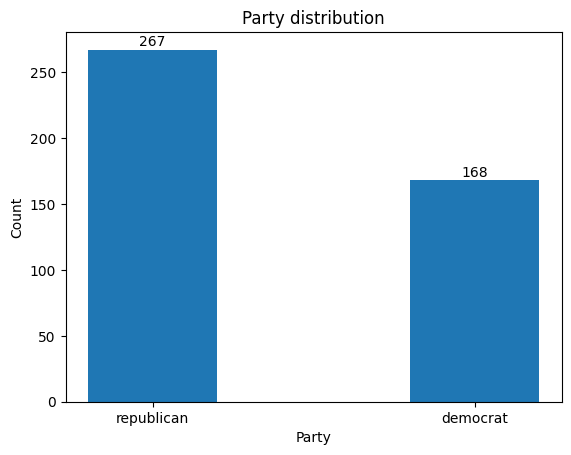

In [ ]:
counts = y_train.value_counts()
bars = plt.bar((-1,1), (counts[1], counts[-1]))
plt.xticks(list(party_map.values()), list(party_map.keys()))
plt.title('Party distribution')
plt.xlabel('Party')
plt.ylabel('Count')

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.5, yval, ha='center', va='bottom')

plt.show()

In [ ]:
vote_map = {'y': 1, 'n': -1, '?':0}
X_train = raw_data.drop('party', axis=1).replace(vote_map)
X_train.head()

/tmp/ipykernel_224/3319808541.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X_train = raw_data.drop('party', axis=1).replace(vote_map)


,vote_1,vote_2,vote_3,vote_4,vote_5,vote_6,vote_7,vote_8,vote_9,vote_10,vote_11,vote_12,vote_13,vote_14,vote_15,vote_16
0,-1,1,-1,1,1,1,-1,-1,-1,1,0,1,1,1,-1,1
1,-1,1,-1,1,1,1,-1,-1,-1,-1,-1,1,1,1,-1,0
2,0,1,1,0,1,1,-1,-1,-1,-1,1,-1,1,1,-1,-1
3,-1,1,1,-1,0,1,-1,-1,-1,-1,1,-1,1,-1,-1,1
4,1,1,1,-1,1,1,-1,-1,-1,-1,1,0,1,1,1,1


In [ ]:
def runSpectralClustering(sigma, dist, type = 'UN'):
  W = eta(dist, sigma)
  D = np.diag(np.sum(W,axis=1))

  #unnormalized graph Laplacian
  if type == 'UN':
    L = D - W
  # random walk Laplacian
  elif(type == 'RW'):
    L = np.eye(D.shape[0]) - np.linalg.inv(D) @ W

  ll, VV = np.linalg.eigh(L)
  idx = ll.argsort()
  l = ll[idx]
  V = VV[:, idx]
  fiedler_vector = V[:, 1]

  return calculateAccuracy(fiedler_vector, y_train), V

In [ ]:
def runSSLClustering(V, M, J, Y, dist):
  Vp = V[0:J, 0:M]

  # Linear Regression
  SSLLinear = LinearRegression().fit(Vp, Y)
  Y_pred_LR = SSLLinear.predict(V[:, 0:M])

  # Ridge Regression
  SSLRidge = Ridge(alpha = 1e-8, fit_intercept=True)
  SSLRidge.fit(Vp, Y)
  Y_pred_ridge = SSLRidge.predict(V[:, 0:M])

  return calculateAccuracy(Y_pred_LR, y_train), calculateAccuracy(Y_pred_ridge, y_train)

In [ ]:
def calculateAccuracy(predictions, true_labels):
  signs = np.sign(predictions)
  flipped_signs = -1 * signs
  accuracy = np.mean(signs == true_labels)
  accuracy_flipped = np.mean(flipped_signs == true_labels)
  return max(accuracy, accuracy_flipped)

def eta(t, sigma):
  val = np.exp(-(t**2/(2*(sigma**2))) )
  return val

sigmas = np.arange(0.1, 4.0, 0.01)
accuracies = []
dist = sp.spatial.distance_matrix(X_train, X_train)
for sigma_val in sigmas:
  result, _ = runSpectralClustering(sigma_val, dist, type = 'UN')
  accuracies.append(result)

accuracies = np.array(accuracies)
print(accuracies)
print(np.max(accuracies))

[0.52643678 0.51034483 0.53563218 0.59770115 0.51494253 0.51724138
 0.53793103 0.53793103 0.50114943 0.51494253 0.56781609 0.60689655
 0.53563218 0.51494253 0.63448276 0.5862069  0.70344828 0.55402299
 0.76781609 0.72873563 0.63678161 0.67816092 0.68275862 0.66666667
 0.64367816 0.79310345 0.77701149 0.68965517 0.76781609 0.70344828
 0.62528736 0.81609195 0.6        0.73103448 0.72873563 0.62758621
 0.61149425 0.61149425 0.61149425 0.61149425 0.61149425 0.61149425
 0.61149425 0.61149425 0.61149425 0.61149425 0.61149425 0.61149425
 0.61149425 0.61149425 0.61149425 0.61149425 0.61149425 0.61149425
 0.61149425 0.61149425 0.61149425 0.61149425 0.61149425 0.61149425
 0.61149425 0.61149425 0.61149425 0.61149425 0.61149425 0.61149425
 0.6091954  0.6091954  0.54252874 0.83448276 0.84827586 0.85287356
 0.85287356 0.85517241 0.85517241 0.85517241 0.85747126 0.86436782
 0.86436782 0.86436782 0.86436782 0.86666667 0.86666667 0.86896552
 0.86896552 0.86896552 0.87126437 0.87356322 0.87356322 0.8735

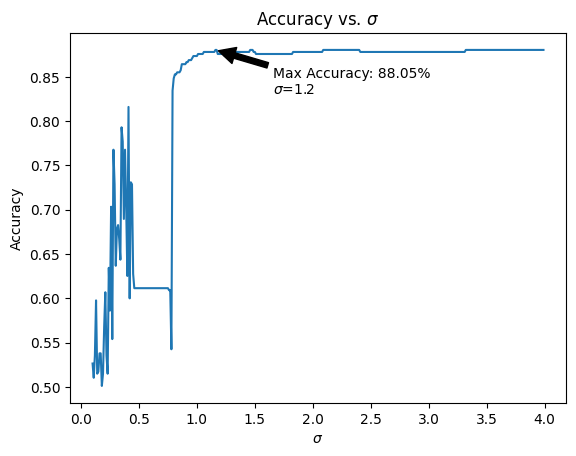

In [ ]:

plt.plot(sigmas, accuracies)

max_acc = np.max(accuracies)
best_sigma = sigmas[np.argmax(accuracies)]

plt.annotate(f'Max Accuracy: {max_acc:.2%}\n$\\sigma$={best_sigma:.1f}',
             xy=(best_sigma, max_acc),
             xytext=(best_sigma + 0.5, max_acc - 0.05),
             arrowprops=dict(facecolor='black', shrink=0.05))

plt.title('Accuracy vs. $\\sigma$')
plt.xlabel('$\\sigma$')
plt.ylabel('Accuracy')
plt.show()

In [30]:
sigma = 1.33
# Get eigenvectors from spectral clustering
#_, V = runSpectralClustering(sigma, dist, type = 'UN')
_, V = runSpectralClustering(sigma, dist, type = 'RW')


M = [2,3,4,5,6]
J = [5,10,20,40]
results = np.zeros((2, len(M), len(J)))
for idx_j, j_val in enumerate(J):
  for idx_m, m_val in enumerate(M):
    Y = y_train[:j_val]
    results[0, idx_m, idx_j], results[1, idx_m, idx_j] = runSSLClustering(V, m_val, j_val, Y, dist)

print(results)

best_linear= np.max(results[0, :, :])
best_ridge = np.max(results[1, :, :])
print(f'*** Sigma: {sigma:.1f} ***')
print(f'Overall best accuracy from Linear Regression: {best_linear:.2%}')
print(f'Overall best accuracy from Ridge Regression: {best_ridge:.2%}')

[[[0.54022989 0.86436782 0.88045977 0.89655172]
  [0.61609195 0.88505747 0.89655172 0.89425287]
  [0.51954023 0.88965517 0.89885057 0.89425287]
  [0.5954023  0.85517241 0.86436782 0.94022989]
  [0.59310345 0.79770115 0.86896552 0.91264368]]

 [[0.54022989 0.86436782 0.88045977 0.89655172]
  [0.61609195 0.88505747 0.89655172 0.89425287]
  [0.52643678 0.88965517 0.89885057 0.89425287]
  [0.5908046  0.85517241 0.86436782 0.94022989]
  [0.59310345 0.79770115 0.87126437 0.91264368]]]
*** Sigma: 1.3 ***
Overall best accuracy from Linear Regression: 94.02%
Overall best accuracy from Ridge Regression: 94.02%


In [24]:
for sigma in np.linspace(0.8, 3.8, 40):
  # Get eigenvectors from spectral clustering
  #_, V = runSpectralClustering(sigma, dist, type = 'UN')
  _, V = runSpectralClustering(sigma, dist, type = 'RW')


  M = [2,3,4,5,6]
  J = [5,10,20,40]
  results = np.zeros((2, len(M), len(J)))
  for idx_j, j_val in enumerate(J):
    for idx_m, m_val in enumerate(M):
      Y = y_train[:j_val]
      results[0, idx_m, idx_j], results[1, idx_m, idx_j] = runSSLClustering(V, m_val, j_val, Y, dist)

  print(results)

  best_linear= np.max(results[0, :, :])
  best_ridge = np.max(results[1, :, :])
  print(f'*** Sigma: {sigma:.6f} ***')
  print(f'Overall best accuracy from Linear Regression: {best_linear:.2%}')
  print(f'Overall best accuracy from Ridge Regression: {best_ridge:.2%}')


[[[0.85287356 0.85057471 0.86436782 0.86666667]
  [0.83678161 0.85517241 0.87356322 0.87586207]
  [0.83908046 0.85287356 0.88275862 0.88505747]
  [0.85057471 0.82068966 0.88505747 0.88505747]
  [0.52873563 0.84827586 0.89195402 0.88965517]]

 [[0.84367816 0.85057471 0.86436782 0.86666667]
  [0.84367816 0.85287356 0.86666667 0.87356322]
  [0.84597701 0.85517241 0.87356322 0.87586207]
  [0.84827586 0.85287356 0.88275862 0.87816092]
  [0.51034483 0.84827586 0.88275862 0.88275862]]]
*** Sigma: 0.800000 ***
Overall best accuracy from Linear Regression: 89.20%
Overall best accuracy from Ridge Regression: 88.28%
[[[0.85287356 0.85517241 0.87126437 0.87356322]
  [0.86206897 0.85747126 0.88735632 0.89425287]
  [0.85057471 0.85517241 0.88965517 0.89885057]
  [0.85057471 0.85517241 0.89655172 0.89655172]
  [0.67816092 0.85747126 0.88735632 0.88965517]]

 [[0.85287356 0.85517241 0.87126437 0.87356322]
  [0.85287356 0.85517241 0.88735632 0.88965517]
  [0.85287356 0.85517241 0.88965517 0.89885057]
 

## Visualizations

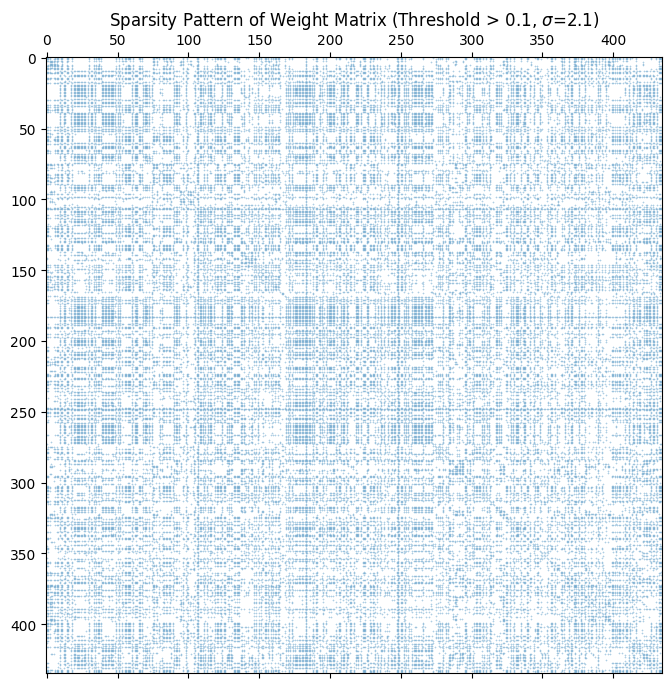

In [31]:
dist = sp.spatial.distance_matrix(X_train, X_train)

def eta(t, sigma):
  val = np.exp(-(t**2/(2*(sigma**2))) )
  return val

# l length scale of the kernel
# l = 0.7*np.median(dist)
l = 2.1

W = eta(dist, l)


plt.figure(figsize=(8, 8))
plt.spy(W, precision=0.1, markersize=0.1)
plt.title(f'Sparsity Pattern of Weight Matrix (Threshold > 0.1, $\\sigma$={l})')
plt.show()

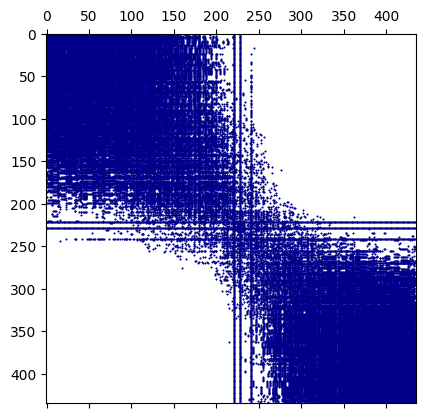

In [32]:
from scipy.sparse import csr_matrix
from scipy.sparse.csgraph import reverse_cuthill_mckee
from scipy.sparse.linalg import eigsh

D = np.diag(np.sum(W,axis=1))
L= D-W

from scipy.sparse.linalg import eigsh

# 1. Compute the first two eigenvectors of L (the Laplacian)
# The smallest eigenvalue is 0 (eigenvector is constant)
# The second smallest is the Fiedler vector
vals, vecs = eigsh(L, k=2, which='SM')
fiedler_vector = vecs[:, 1]

# 2. Get the permutation by sorting the Fiedler vector values
perm_fiedler = np.argsort(fiedler_vector)

# 3. Reorder and plot
L_fiedler = L[perm_fiedler][:, perm_fiedler]
plt.spy(L_fiedler,precision=0.1, markersize=0.5, color='darkblue')


In [ ]:
# fig, ax = plt.subplots(1,2, figsize=(16,8))

# ax[0].plot(np.log(vecs[0:10]))
# ax[0].set_title('Unnormalized eigenvalues')
# ax[0].set_xlabel('index')
# ax[0].set_ylabel('$\\lambda$')


# ax[1].plot(np.log(vecs[0:10]))
# ax[1].set_title('Normalized eigenvalues')
# ax[0].set_xlabel('index')
# ax[0].set_ylabel('$\\lambda$')

## Development Code

In [ ]:
# M = [2,3,4,5,6]
# J = [5,10,20,40]
# Y = y_train[:J]

# # Get eigenvectors from spectral clustering
# _, V = runSpectralClustering(2.1, sp.spatial.distance_matrix(X_train, X_train), type = 'UN')

# # Fix: Select first J samples (rows) and first M eigenvectors (columns)
# # V[:, 0:M] gives us the first M eigenvectors for all samples
# Vp = V[0:J, 0:M]

# # Linear Regression
# SSLLinear = LinearRegression().fit(Vp, Y)

# # Predict for all samples using the predict method to include the intercept
# Y_pred_LR = SSLLinear.predict(V[:, 0:M])
# accuracy_LR = calculateAccuracy(Y_pred_LR, y_train)

# # Ridge Regression
# SSLRidge = Ridge(alpha = 1e-8, fit_intercept=True)
# SSLRidge.fit(Vp, Y)

# Y_pred_ridge = SSLRidge.predict(V[:, 0:M])
# accuracy_ridge = calculateAccuracy(Y_pred_ridge, y_train)

# print(f"Accuracy using Linear Regression: {accuracy_LR:.2%}")
# print(f"Accuracy using Ridge Regression: {accuracy_ridge:.2%}")

In [ ]:
# FX = V[:, 1:M+1]

# FX = FX / np.abs(FX).max(axis=0)

# FXn = Vn[:, 1:M+1]

# FXn = FXn / np.abs(FXn).max(axis=0)

# KMM = skl.cluster.KMeans(n_clusters=2, random_state=0).fit(FX)

# KMMn = skl.cluster.KMeans(n_clusters=2, random_state=0).fit(FXn)

In [ ]:
# D = np.diag(np.sum(W,axis=1))

# #unnormalized graph Laplacian
# L = D - W

# #RW Laplacian
# Ln = np.eye(D.shape[0]) - np.linalg.inv(D) @ W

# # compute eigendecompositions for L and Ln

# ll, VV = np.linalg.eigh(L)
# idx = ll.argsort()
# l = ll[idx]
# V = VV[:, idx]

# lln, VVn = np.linalg.eigh(Ln)
# idxn = lln.argsort()
# ln = lln[idxn]
# Vn = VVn[:, idxn]


In [ ]:
# fiedler_vector1 = V[:, 1]
# y_pred_unnormalized = np.where(fiedler_vector1 > 0, 1, -1)

# accuracy = np.mean(y_pred_unnormalized == y_train)

# accuracy_flipped = np.mean((-1 * y_pred_unnormalized) == y_train)

# final_accuracy = max(accuracy, accuracy_flipped)

# print(f"Accuracy using Fiedler vector (Unnormalized): {final_accuracy:.2%}")

# fiedler_vector2 = Vn[:, 1]
# y_pred_normalized = np.where(fiedler_vector2 > 0, 1, -1)

# accuracy = np.mean(y_pred_normalized == y_train)

# accuracy_flipped = np.mean((-1 * y_pred_normalized) == y_train)

# final_accuracy = max(accuracy, accuracy_flipped)

# print(f"Accuracy using Fiedler vector (Normalized): {final_accuracy:.2%}")